# 04 — Model Evaluation
Loads the trained model from MLflow and evaluates it on the **test set** (202401–202512).

Covers:
- ROC AUC y PR AUC
- ROC curve y Precision-Recall curve
- Calibration curve
- Score distribution por clase
- Confusion matrix al threshold óptimo (F1)
- SHAP feature importance (TreeExplainer)
- SHAP summary plot (beeswarm)
- AUC por período (estabilidad temporal)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from src.features import prepare_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [2]:
with open('../params.yaml') as f:
    params = yaml.safe_load(f)

test_df = pd.read_parquet(f"../{params['data']['test_path']}")
X_test, y_test = prepare_features(test_df, params_path='../params.yaml')
print(f"Test shape: {X_test.shape}  |  Default rate: {y_test.mean():.4f}")

Test shape: (316067, 13)  |  Default rate: 0.0699


## 1. Cargar modelo
> Intenta desde MLflow. Si no está disponible entrena un LightGBM local como fallback.

In [3]:
import mlflow

MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', params['mlflow']['tracking_uri'])
MODEL_URI  = os.getenv('MODEL_URI', params['api']['model_uri'])
mlflow.set_tracking_uri(MLFLOW_URI)

try:
    pipeline = mlflow.sklearn.load_model(MODEL_URI)
    print(f"Modelo cargado desde MLflow: {MODEL_URI}")
except Exception as e:
    print(f"MLflow no disponible ({e}).\nEntrenando LightGBM local...")
    from lightgbm import LGBMClassifier
    from src.features import build_full_pipeline

    train_df = pd.read_parquet(f"../{params['data']['train_path']}")
    X_tr, y_tr = prepare_features(train_df, params_path='../params.yaml')
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    pipeline = build_full_pipeline(
        LGBMClassifier(n_estimators=200, scale_pos_weight=neg / pos, random_state=42, verbosity=-1)
    )
    pipeline.fit(X_tr, y_tr)
    print("Modelo local entrenado.")

MLflow no disponible (API request to endpoint /api/2.0/mlflow/registered-models/get-latest-versions failed with error code 403 != 200. Response body: '').
Entrenando LightGBM local...
Modelo local entrenado.


In [4]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

gate = params['model']['auc_threshold']
print(f"ROC AUC : {auc:.4f}")
print(f"PR  AUC : {pr_auc:.4f}")
print(f"AUC gate: {gate}  →  {'PASS ✓' if auc >= gate else 'FAIL ✗'}")

ROC AUC : 0.9944
PR  AUC : 0.9467
AUC gate: 0.87  →  PASS ✓


## 2. ROC y Precision-Recall curves

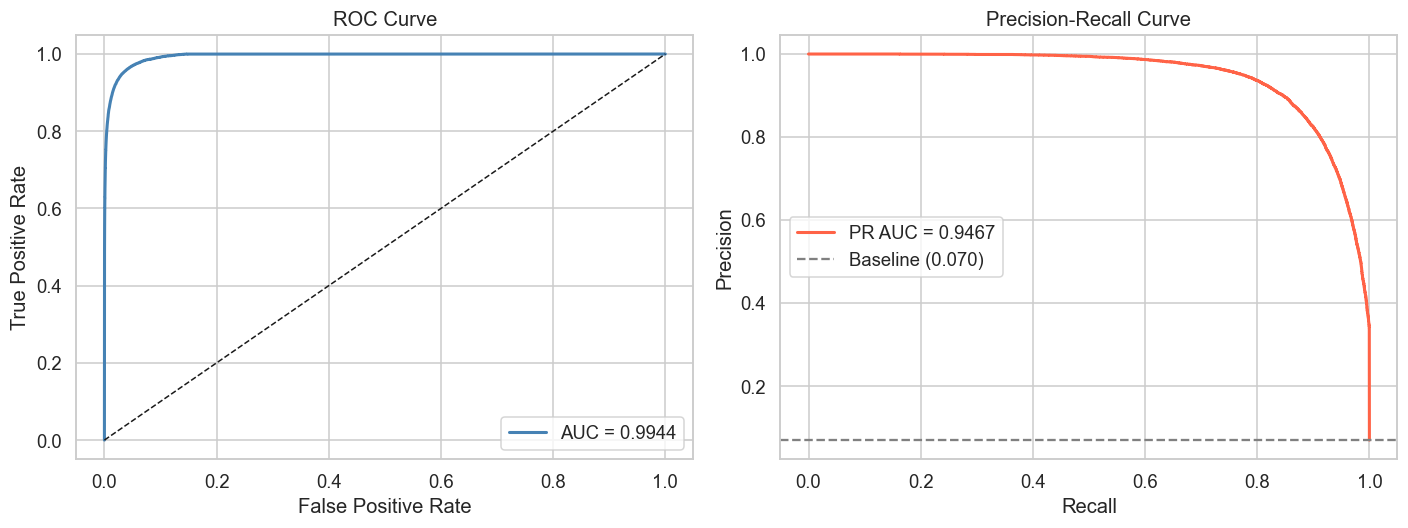

In [5]:
fpr, tpr, _          = roc_curve(y_test, y_prob)
prec, rec, pr_thresh = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(rec, prec, color='tomato', lw=2, label=f'PR AUC = {pr_auc:.4f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Score distribution por clase

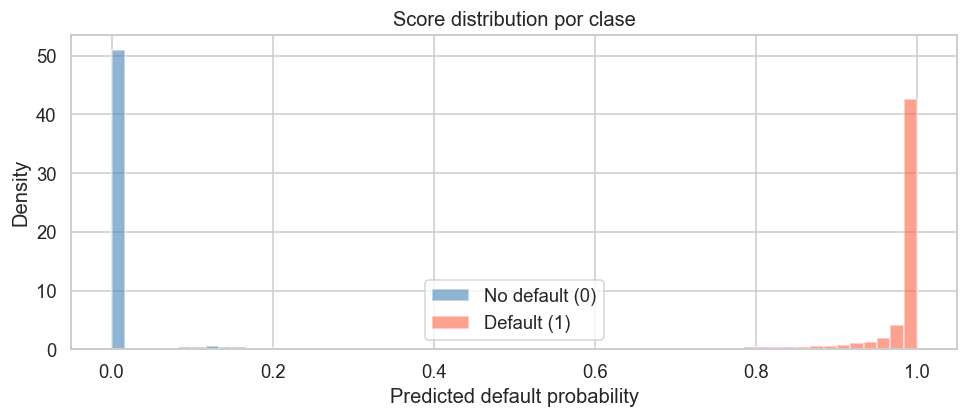

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_prob[y_test == 0], bins=60, alpha=0.6, label='No default (0)', color='steelblue', density=True)
ax.hist(y_prob[y_test == 1], bins=60, alpha=0.6, label='Default (1)',    color='tomato',    density=True)
ax.set_xlabel('Predicted default probability')
ax.set_ylabel('Density')
ax.set_title('Score distribution por clase')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Threshold óptimo y confusion matrix

Threshold óptimo (max F1): 0.9068  |  F1: 0.8730


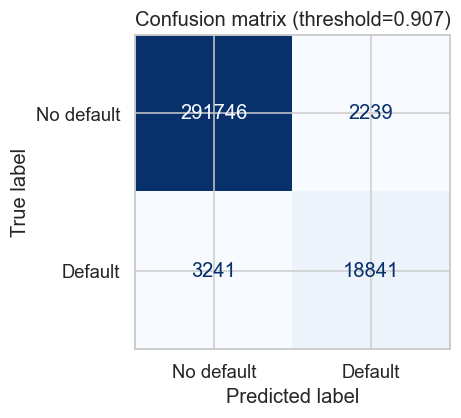

In [7]:
# F1 vectorizado sobre los arrays de precision_recall_curve (sin loop)
with np.errstate(invalid='ignore'):
    f1_arr = 2 * prec * rec / (prec + rec)
f1_arr = np.nan_to_num(f1_arr)

best_idx    = int(np.argmax(f1_arr))
best_thresh = float(pr_thresh[best_idx]) if best_idx < len(pr_thresh) else 0.5
print(f"Threshold óptimo (max F1): {best_thresh:.4f}  |  F1: {f1_arr[best_idx]:.4f}")

y_pred = (y_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No default', 'Default']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion matrix (threshold={best_thresh:.3f})')
plt.tight_layout()
plt.show()

## 5. Calibration curve

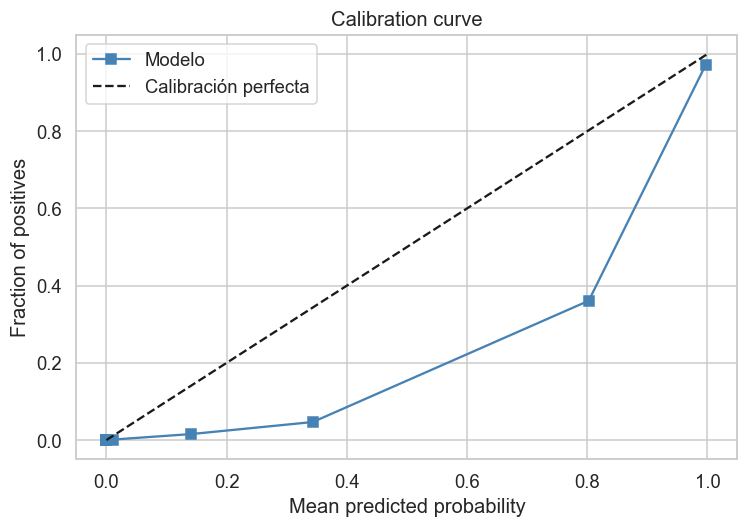

In [8]:
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=20, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, fraction_pos, marker='s', color='steelblue', label='Modelo')
ax.plot([0, 1], [0, 1], 'k--', label='Calibración perfecta')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()

## 6. SHAP feature importance

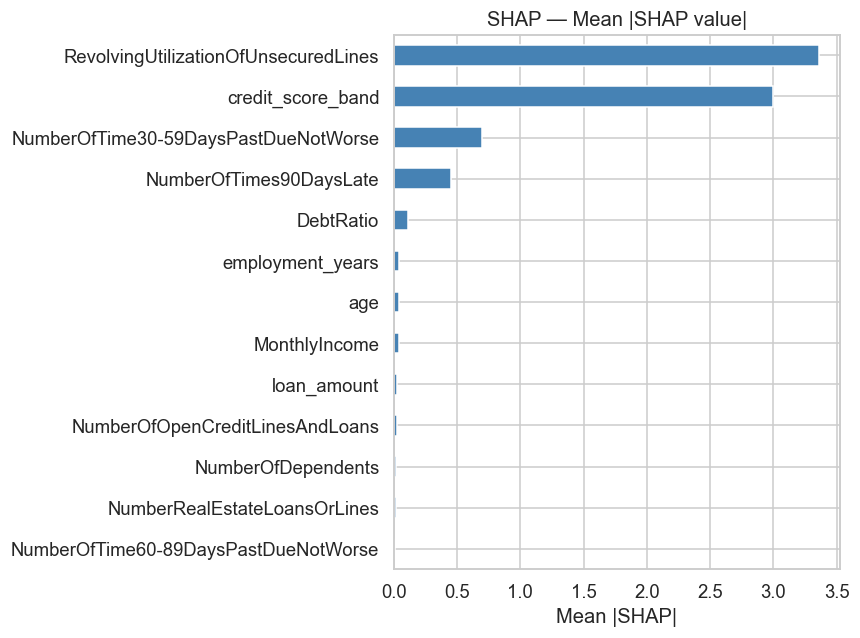

In [9]:
import shap

X_transformed = pipeline[:-1].transform(X_test)
model_step    = pipeline[-1]

try:
    explainer = shap.TreeExplainer(model_step)

    sample_size = min(2000, len(X_transformed))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_transformed), size=sample_size, replace=False)
    shap_values = explainer.shap_values(X_transformed[idx])

    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    from src.features import get_feature_names_out
    preprocessor_step = pipeline.named_steps.get('preprocessor')
    feat_names = (
        get_feature_names_out(preprocessor_step)
        if preprocessor_step is not None
        else [f'f{i}' for i in range(X_transformed.shape[1])]
    )

    shap_df = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    shap_df.plot.barh(ax=ax, color='steelblue')
    ax.set_title('SHAP — Mean |SHAP value|')
    ax.set_xlabel('Mean |SHAP|')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP TreeExplainer no disponible: {e}")

## 7. SHAP summary plot (beeswarm)

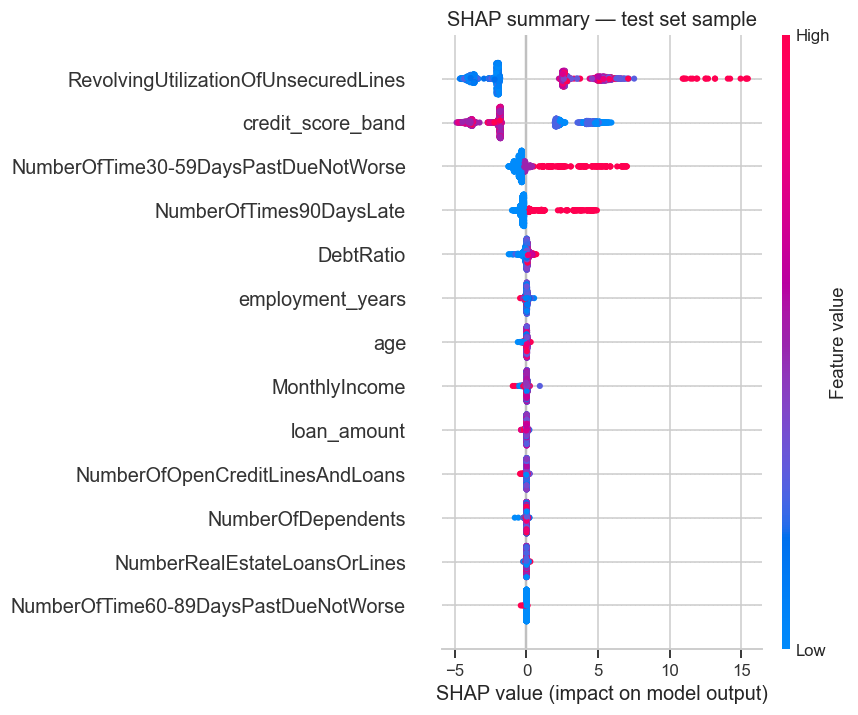

In [10]:
try:
    shap.summary_plot(
        sv, X_transformed[idx],
        feature_names=feat_names,
        plot_type='dot',
        max_display=13,
        show=False,
    )
    plt.title('SHAP summary — test set sample')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP summary plot: {e}")

## 8. AUC por período (estabilidad temporal)

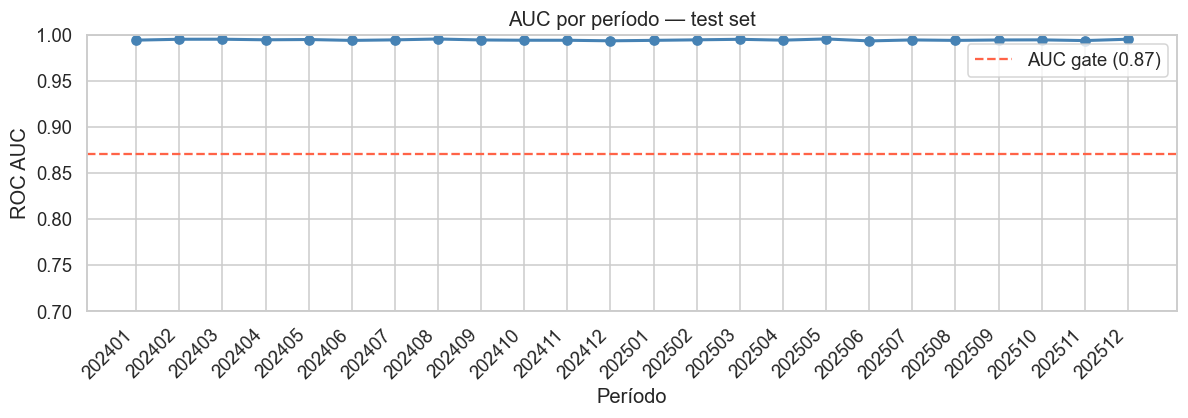

In [11]:
period_col = params['features']['period_col']

test_df_eval = test_df[[period_col]].copy()
test_df_eval['y_prob'] = y_prob
test_df_eval['y_true'] = y_test.values

perf = (
    test_df_eval.groupby(period_col)
    .apply(lambda g: roc_auc_score(g['y_true'], g['y_prob']) if g['y_true'].nunique() > 1 else float('nan'))
    .rename('auc')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(perf[period_col].astype(str), perf['auc'], marker='o', color='steelblue', linewidth=2)
ax.axhline(gate, color='tomato', linestyle='--', label=f'AUC gate ({gate})')
ax.set_xlabel('Período')
ax.set_ylabel('ROC AUC')
ax.set_title('AUC por período — test set')
ax.set_ylim(0.7, 1.0)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()